In [ ]:
#Task 3: Clustering Analysis
# Import libraries 
ifrom sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
# 1.  Iris dataset
df_iris = pd.read_csv('1) iris.csv')

print("--- Data Info ---")
df_iris.info()
print("\n--- Missing Values ---")
print(df_iris.isnull().sum())
print("\n--- Summary Statistics ---")
display(df_iris.describe())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

--- Missing Values ---
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

--- Summary Statistics ---


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


c:\Users\bhatt\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\bhatt\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\bhatt\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\bhatt\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

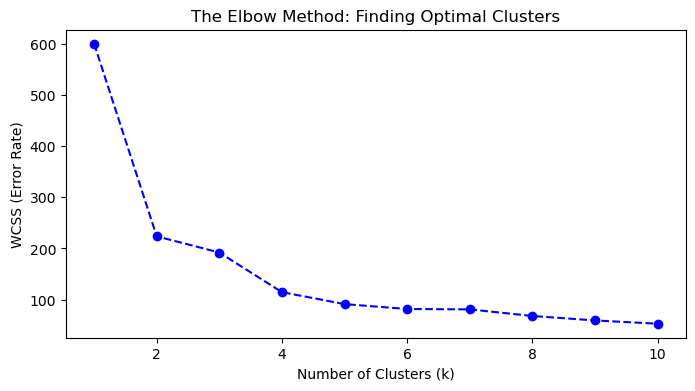

In [8]:
# Selecting only the numerical columns for our clustering 
X_kmeans = df_iris.select_dtypes(include=['float64', 'int64'])

#We can drop Id column , because it is an Label and not a measurement
if 'Id' in X_kmeans.columns:
    X_kmeans = X_kmeans.drop('Id', axis=1)

# Standardize the dataset to ensure all measurements weigh equally
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_kmeans)

# 3. Determine optimal clusters using the Elbow Method
wcss = [] 
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method: Finding Optimal Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Error Rate)')
plt.show()


c:\Users\bhatt\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



--- Final K-Means Clustering Applied (k=3) ---


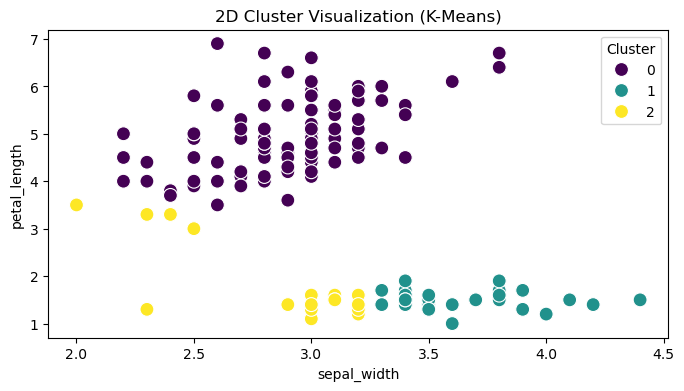

In [9]:
# Apply K-Means and Visualize Clusters
# The elbow above bends at 3, which is standard for the Iris dataset
optimal_clusters = 3
kmeans_final = KMeans(n_clusters=optimal_clusters, random_state=42, n_init='auto')
df_iris['Cluster_Label'] = kmeans_final.fit_predict(X_scaled)

print(f"\n--- Final K-Means Clustering Applied (k={optimal_clusters}) ---")

# Clusters using a 2D scatter plot
plt.figure(figsize=(8, 4))
sns.scatterplot(
    x=df_iris.columns[1], # Usually SepalLength
    y=df_iris.columns[2], # Usually SepalWidth
    hue='Cluster_Label', 
    data=df_iris, 
    palette='viridis', 
    s=100
)
plt.title('2D Cluster Visualization (K-Means)')
plt.legend(title='Cluster')
plt.show()